# Homework 2: Arrays and Tables

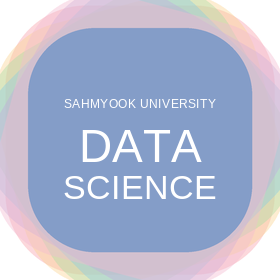

Please complete this notebook by filling in the cells provided. Before you begin, execute the previous cell to load the provided tests.

**Helpful Resource:**
- [Python Reference](http://data8.org/sp26/reference/): Cheat sheet of helpful array & table methods used in this data science course!

**Recommended Readings:**
- [Arrays](https://inferentialthinking.com/chapters/05/1/Arrays.html)
- [What is Data Science?](http://www.inferentialthinking.com/chapters/01/what-is-data-science.html)
- [Causality and Experiments](http://www.inferentialthinking.com/chapters/02/causality-and-experiments.html) 
- [Programming in Python](http://www.inferentialthinking.com/chapters/03/programming-in-python.html)

For all problems that you must write explanations and sentences for, you **must** provide your answer in the designated space. Moreover, throughout this homework and all future ones, **please be sure to not re-assign variables throughout the notebook!** For example, if you use `max_temperature` in your answer to one question, do not reassign it later on. Otherwise, you will fail tests that you thought you were passing previously!

Directly sharing answers is not okay, but discussing problems with the course staff or with other students is encouraged.

You should start early so that you have time to get help if you're stuck.

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/hw/hw02')
os.makedirs('tests', exist_ok=True)
with open('hw02.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('hw02.ipynb')
print('Ready! (28 tests loaded)')

In [ ]:
# Run this cell and ignore the output. It is checking to see if you ran the first cell! 
# If you get a NameError, please run the cell at the very TOP of this notebook!

grader

In [ ]:
# Run this cell to set up the notebook, but please don't change it.

import numpy as np
from datascience import *
import warnings
warnings.simplefilter('ignore', FutureWarning)

# These lines do some fancy plotting magic.\n",
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')


# No need to worry about what this code means
from IPython.display import Javascript, display
display(Javascript(r"""
(() => {
  function pathLooksLikeTyping(e) {
    const path = e.composedPath ? e.composedPath() : [];
    for (const n of path) {
      if (!n) continue;
      if (n.tagName === 'INPUT' || n.tagName === 'TEXTAREA') return true;
      if (n.isContentEditable) return true;
      const role = n.getAttribute?.('role');
      if (role === 'textbox' || role === 'combobox' || role === 'searchbox') return true;
      const ariaMulti = n.getAttribute?.('aria-multiline');
      if (ariaMulti === 'true') return true;
      const cls = (n.className || "").toString().toLowerCase();
    }
    return false;
  }
  function handler(e) {
    if (e.key !== 'o' && e.key !== 'O') return;
    if (pathLooksLikeTyping(e)) {
      e.stopPropagation();
      if (e.stopImmediatePropagation) e.stopImmediatePropagation();
      if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
      return;
    }
    e.preventDefault();
    e.stopPropagation();
    if (e.stopImmediatePropagation) e.stopImmediatePropagation();
    if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
  }
  window.addEventListener('keydown', handler, true);
  window.addEventListener('keypress', handler, true);
  console.log("Installed: 'o' won't toggle output; 'o' should type inside any textbox-like UI (including JupyTutor).");
})();
"""))

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Indexing Arrays

These exercises give you practice on accessing individual elements of arrays. In Python, each element is accessed by its index. An index indicates the position of an element within an array. For example, the first element is the element at index 0. Indices must be **integers**.

***Note:* If you have previous coding experience, you may be familiar with bracket notation. DO NOT use bracket notation when indexing (i.e. `arr[0]`).**

Be sure to refer to the [Python Reference](http://data8.org/sp26/reference/) on the website if you feel stuck!

---

**Question 1.1.** The cell below creates an array of some numbers.  Set `third_element` to the third element of `some_numbers` using `item`. **(3 Points)**

_**Hint:** Remember that the first element is at index 0, the second element is at index 1, and so on!_


In [ ]:
some_numbers = make_array(-1, -3, -6, -10, -15)

third_element = ...
third_element

In [ ]:
grader.check("q1_1")

---

**Question 1.2.** The next cell creates a table that displays some information about the elements of `some_numbers` and their order.  Run the cell to see the partially-completed table, then fill in the missing information (the cells that say "Ellipsis") by assigning `blank_a`, `blank_b`, `blank_c`, and `blank_d` to the correct elements in the table. **(4 Points)**

*Note:* Replace the `...` with strings or numbers. As a reminder, indices should be **integers**.

*Hint:* If you're confused about which location corresponds to each blank, try filling in one blank and seeing how the table changes!

In [ ]:
blank_a = ...
blank_b = ...
blank_c = ...
blank_d = ...
elements_of_some_numbers = Table().with_columns(
    "English name for position", make_array("first", "second", blank_a, blank_b, "fifth"),
    "Index",                     make_array(blank_c, 1, 2, blank_d, 4),
    "Element",                   some_numbers)
elements_of_some_numbers

In [ ]:
grader.check("q1_2")

---

**Question 1.3.** You'll sometimes want to find the **last** element of an array.  Suppose an array has 142 elements.  What is the index of its last element? **(3 Points)**

*Note:* Your answer must be a positive integer. An integer is a whole number that does not include fractions or decimals.


In [ ]:
index_of_last_element = ...

In [ ]:
grader.check("q1_3")

More often, you don't know the number of elements in an array, which is its *length*.  (For example, it might be a large dataset you found on the Internet.)  The function `len` takes a single argument, an array, and returns an integer that represents the `len`gth of that array. You can see an example of `len` here:

In [ ]:
#Creating an array with five elements
five_element_array = make_array(1, 2, 3, 4, 5)

#Finding the length of the array, which is 5!
len(five_element_array)

**Question 1.4.** The cell below loads an array called `president_birth_years`.  Calling `tbl.column(...)` on a table returns an array of the column specified, in this case the `Birth Year` column of the `president_births` table. The last element in that array is the most recent among the birth years of all the deceased Presidents. Assign that year to `most_recent_birth_year`. **(4 Points)**

**Note:** Do not Google the answer. You should be able to answer this question only using array methods.


In [ ]:
president_birth_years = Table.read_table("president_births.csv").column('Birth Year')

most_recent_birth_year = ...
most_recent_birth_year

In [ ]:
grader.check("q1_4")

---

**Question 1.5.** Finally, assign `min_of_birth_years` to the minimum of the first, sixteenth, and last birth years listed in `president_birth_years`. **(4 Points)**

**Note:** Use the Python `min` function and table methods to find the answer. Do not manually calculate the result yourself!


In [ ]:
min_of_birth_years = ...
min_of_birth_years

In [ ]:
grader.check("q1_5")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Basic Array Arithmetic

---

**Question 2.1.** Multiply the numbers 42, -4224, 424224242, and 250 by 157. Assign each variable below such that `first_product` is assigned to the result of $42 * 157$, `second_product` is assigned to the result of $-4224 * 157$, and so on. **(3 Points)**

*Note*: For this question, **don't** use arrays.


In [ ]:
first_product = ...
second_product = ...
third_product = ...
fourth_product = ...
print("First Product:", first_product)
print("Second Product:", second_product)
print("Third Product:", third_product)
print("Fourth Product:", fourth_product)

In [ ]:
grader.check("q2_1")

---

**Question 2.2.** Now, do the same calculation, but using an array called `numbers` and only a single multiplication (`*`) operator.  Store the 4 results in an array named `products`. **(3 Points)**


In [ ]:
numbers = ...
products = ...
products

In [ ]:
grader.check("q2_2")

---

**Question 2.3.** Oops, we made a typo!  Instead of 157, we wanted to multiply each number by 1577.  Compute the correct products in the cell below using array arithmetic.  Notice that your job is really easy if you previously defined an array containing the 4 numbers. **(3 Points)**


In [ ]:
correct_products = ...
correct_products

In [ ]:
grader.check("q2_3")

---

**Question 2.4.** We've loaded an array of temperatures in the next cell.  Each number is the highest temperature observed on a day at a climate observation station, mostly from the US.  Since they're from the US government agency [NOAA](https://www.noaa.gov/), all the temperatures are in Fahrenheit.

Convert all the temperatures to Celsius by first subtracting 32 from them, then multiplying the results by $\frac{5}{9}$, i.e. $C = (F - 32) * \frac{5}{9}$. After converting the temperatures to Celsius, make sure to **ROUND** the final result  to the nearest integer using the `np.round` function. **(4 Points)**


In [ ]:
max_temperatures = Table.read_table("temperatures.csv").column("Daily Max Temperature")

max_temperatures_celsius = ...
celsius_temps_rounded = ...
celsius_temps_rounded

In [ ]:
grader.check("q2_4")

---

**Question 2.5.** The cell below loads all the *lowest* temperatures from each day (in Fahrenheit).  Compute the daily temperature range for each day. That is, compute the difference between each daily maximum temperature and the corresponding daily minimum temperature.  **Pay attention to the units and give your answer in Celsius!** <span style="color:red">Make sure **NOT** to round your answer for this question!</span> **(3 Points)**

*Hint:* Use `min_temperatures` and/or `max_temperatures`, and be careful with when you perform your unit conversions. Write out the mathematical computation by hand if you're stuck!



In [ ]:
min_temperatures = Table.read_table("temperatures.csv").column("Daily Min Temperature")

celsius_temperature_ranges = ...
celsius_temperature_ranges

In [ ]:
grader.check("q2_5")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 3. Old Faithful

Old Faithful is a geyser in Yellowstone that erupts every 44 to 125 minutes (according to [Wikipedia](https://en.wikipedia.org/wiki/Old_Faithful)). People are often told that the geyser erupts every hour, but in fact the waiting time between eruptions is more variable. Let's take a look.

---

**Question 3.1.** The first line below assigns `waiting_times` to an array of 272 consecutive waiting times between eruptions, taken from a classic 1938 dataset. Assign the names `shortest`, `longest`, and `average` so that the `print` statement is correct. **(4 Points)**


In [ ]:
waiting_times = Table.read_table('old_faithful.csv').column('waiting')

shortest = ...
longest = ...
average = ...

print("Old Faithful erupts every", shortest, "to", longest, "minutes and every", average, "minutes on average.")

In [ ]:
grader.check("q3_1")

---

**Question 3.2.** Assign `biggest_decrease` to the biggest decrease in waiting time between two consecutive eruptions. For example, the third eruption occurred after 74 minutes and the fourth after 62 minutes, so the decrease in waiting time was 74 - 62 = 12 minutes. **(4 Points)**

*Hint*: We want to return the absolute value of the biggest decrease.

*Note*: `np.diff()` calculates the difference between subsequent values in an array. For example, calling `np.diff()` on the array `make_array(1, 8, 3, 5)` evaluates to `array([8 - 1, 3 - 8, 5 - 3])`, or `array([7, -5, 2])`. In this array, the biggest decrease would be from the second eruption to the third eruption.


In [ ]:
# np.diff() calculates the difference between subsequent values in a NumPy array
# where the first value is subtracted from the second value

differences = np.diff(waiting_times)
biggest_decrease = ...
biggest_decrease

In [ ]:
grader.check("q3_2")

---

**Question 3.3.** The `faithful_with_eruption_nums` table contains two columns: `eruption_number`, which represents the number of that eruption, and `waiting`, which represents the time spent waiting after that eruption. For example, take the first two rows of the table:

| eruption number | waiting |
|-----------------|---------|
| 1               | 79      |
| 2               | 54      |

We can read this as follows: after the first eruption, we waited 79 minutes for the second eruption. Then, after the second eruption, we waited 54 minutes for the third eruption.

Suppose Dylan and Tim started watching Old Faithful at the start of the first eruption. Assume that they watch until the end of the tenth eruption. For some of that time they will be watching eruptions, and for the rest of the time they will be waiting for Old Faithful to erupt. How many minutes will they spend waiting for eruptions? **(4 Points)**

*Hint #1:* You can start by using the `take` method on the table `faithful_with_eruption_nums`. 

*Hint #2:* `first_nine_waiting_times` must be an array.


In [ ]:
# The following two lines load in our faithful_with_eruption_nums table
faithful = Table.read_table('old_faithful.csv').drop("eruptions")
faithful_with_eruption_nums = faithful.with_column("eruption number", np.arange(faithful.num_rows) + 1).select(1, 0)

first_nine_waiting_times = ...
total_waiting_time_until_tenth = ...
total_waiting_time_until_tenth

In [ ]:
grader.check("q3_3")

---

**Question 3.4.** Let’s imagine your guess for the next waiting time was always just the length of the previous waiting time. If you always guessed the previous waiting time, how big would your error in guessing the waiting times be, on average? **(4 Points)**

For example, since the first four waiting times are 79, 54, 74, and 62, the average difference between your guess and the actual time for just the second, third, and fourth eruptions would be $\frac{|79-54|+ |54-74|+ |74-62|}{3} = 19$.


In [ ]:
differences = np.diff(waiting_times)
average_error = ...
average_error

In [ ]:
grader.check("q3_4")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 4. Tables

---

**Question 4.1.** Suppose you have 4 apples, 3 oranges, and 3 pineapples.  (Perhaps you're using Python to solve a high school Algebra problem.)  Create a table that contains this information.  It should have two columns: `fruit name` and `amount`.  Assign the new table to the variable `fruits`. **(4 Points)**

*Note:* Use lower-case and singular words for the name of each fruit, like `"apple"`.

*Note:* Review [Chapter 6](https://inferentialthinking.com/chapters/06/Tables.html) if you get stuck!


In [ ]:
# Our solution uses 1 statement split over 3 lines.
fruits = ...
        ...
        ...
fruits

In [ ]:
grader.check("q4_1")

---

**Question 4.2.** The file `inventory.csv` contains information about the inventory at a fruit stand.  Each row represents the contents of one box of fruit. Load it as a table named `inventory` using the `Table.read_table()` function. `Table.read_table(...)` takes one argument (data file name in string format) and returns a table. **(4 Points)**


In [ ]:
inventory = ...
inventory

In [ ]:
grader.check("q4_2")

---

**Question 4.3.** Does each box at the fruit stand contain a different fruit? Set `all_different` to `True` if each box contains a different fruit or to `False` if multiple boxes contain the same fruit. **(4 Points)**

*Hint:* You don't have to write code to calculate the True/False value for `all_different`. Just look at the `inventory` table and assign `all_different` to either `True` or `False` according to what you can see from the table in answering the question.

*Note:* Make sure to capitalize `True` and `False`!


In [ ]:
all_different = ...
all_different

In [ ]:
grader.check("q4_3")

---

**Question 4.4.** The file `sales.csv` contains the number of fruit sold from each box last Saturday.  It has an extra column called `price per fruit ($)` that's the price *per item of fruit* for fruit in that box.  The rows are in the same order as the `inventory` table.  Load these data into a table called `sales`. **(5 Points)**


In [ ]:
sales = ...
sales

In [ ]:
grader.check("q4_4")

---

**Question 4.5.** How many fruits did the store sell in total on that day? **(5 Points)**


In [ ]:
total_fruits_sold = ...
total_fruits_sold

In [ ]:
grader.check("q4_5")

---

**Question 4.6.** What was the store's total revenue (the total price of all fruits sold) on that day? **(5 Points)**

*Hint:* If you're stuck, think first about how you would compute the total revenue from just the grape sales.


In [ ]:
total_revenue = ...
total_revenue

In [ ]:
grader.check("q4_6")

---

**Question 4.7.** Make a new table called `remaining_inventory`.  It should have the same rows and columns as `inventory`, except that the amount of fruit sold from each box should be subtracted from that box's **original** count, so that the `count` column is **updated to be** the amount of fruit remaining after Saturday. **(5 Points)**


In [ ]:
remaining_inventory = ...
    ...
    ...
    ...
remaining_inventory

In [ ]:
grader.check("q4_7")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 5. Unemployment

The Great Recession of 2008-2009 was a period of economic decline observed globally, with scale and timing varying from country to country. In the United States, it resulted in a rapid rise in unemployment that affected industries and population groups to different extents.

The Federal Reserve Bank of St. Louis publishes data about jobs in the US.  Below, we've loaded data on unemployment in the United States. There are many ways of defining unemployment, and our dataset includes two notions of the unemployment rate:

1. *Non-Employment Index (or NEI)*: Among people who are able to work and are looking for a full-time job, the percentage who can't find a job.
2. *NEI-PTER*: Among people who are able to work and are looking for a full-time job, the percentage who can't find any job *or* are only working at a part-time job.  The latter group is called "Part-Time for Economic Reasons", so the acronym for this index is NEI-PTER.  (Economists are great at marketing.)

The source of the data is [at the St. Louis Fed (FRED)](https://fred.stlouisfed.org/categories/33509).

---

**Question 5.1.** The data are in a CSV file called `unemployment.csv`.  Load that file into a table called `unemployment`. **(1 Point)**

_Hint:_ After loading in the CSV file, the `unemployment` table should look like this:

<img alt="Preview of a data table with columns Date, NEI, and NEI-PTER showing quarterly unemployment-index values from 1994 onward, with most rows omitted." src="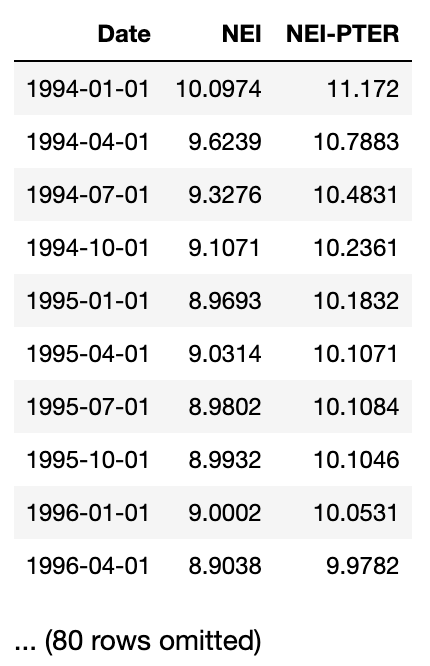" width="20%"/>


In [ ]:
unemployment = ...
unemployment

In [ ]:
grader.check("q5_1")

---

**Question 5.2.** Sort the data in descending order by NEI, naming the sorted table `by_nei`.  Create another table called `by_nei_pter` that's sorted in descending order by NEI-PTER instead. **(4 Points)**


In [ ]:
by_nei = ...
by_nei_pter = ...

In [ ]:
grader.check("q5_2")

In [ ]:
# Run this cell to check your by_nei table. You do not need to change the code.
by_nei.show(5)

In [ ]:
# Run this cell to check your by_nei_pter table. You do not need to change the code.
by_nei_pter.show(5)

---

**Question 5.3.** Using `take`, assign `greatest_nei` to a table containing the data for the 11 quarters when NEI was greatest.

`greatest_nei` should be sorted in descending order of `NEI`. Note that each row of `unemployment` represents a quarter. **(2 Points)**


In [ ]:
greatest_nei = ...
greatest_nei

In [ ]:
grader.check("q5_3")

---

**Question 5.4.** It's believed that many people became PTER (recall: "Part-Time for Economic Reasons") in the "Great Recession" of 2008-2009.  NEI-PTER is the percentage of people who are unemployed (included in the NEI) plus the percentage of people who are PTER.

Compute an array containing the percentage of people who were PTER in each quarter.  (The first element of the array should correspond to the first row of `unemployment`, and so on.) **(3 Points)**

*Note:* Use the original `unemployment` table for this.


In [ ]:
pter = ...
pter

In [ ]:
grader.check("q5_4")

---

**Question 5.5.** Add `pter` as a column to `unemployment` (name the column `PTER`) and sort the resulting table by that column in descending order.  Call the resulting table `by_pter`.

Try to do this with a single line of code, if you can. **(3 Points)**


In [ ]:
by_pter = ...
by_pter

In [ ]:
grader.check("q5_5")

---

**Question 5.6.** Create a line plot of PTER over time. To do this, create a new table called `pter_over_time` with the same columns as the `unemployment` table with the addition of two new columns: `Year` and `PTER` using the `year` array and the `pter` array, respectively. Then, generate a line plot using one of the table methods you've learned in class.

The order of the columns matter for our correctness tests, so be sure `Year` comes before `PTER`. **(4 Points)**

*Note:* When constructing `pter_over_time`, do not just add the `year` column to the `by_pter` table. Please follow the directions in the question above.


In [ ]:
year = 1994 + np.arange(by_pter.num_rows)/4
pter_over_time = ...
...
plt.ylim(0,2); # Do not change this line

In [ ]:
grader.check("q5_6")

---

**Question 5.7.** Were PTER rates high during the Great Recession (that is to say, were PTER rates particularly high in the years 2008 through 2011)? Assign `highPTER` to `True` if you think PTER rates were high in this period, or `False` if you think they weren't. **(1 Points)**


In [ ]:
highPTER = ...

In [ ]:
grader.check("q5_7")

You're done with Homework 2!  

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


## Pets of this data science course

Nico is proud of you for completing another homework! 

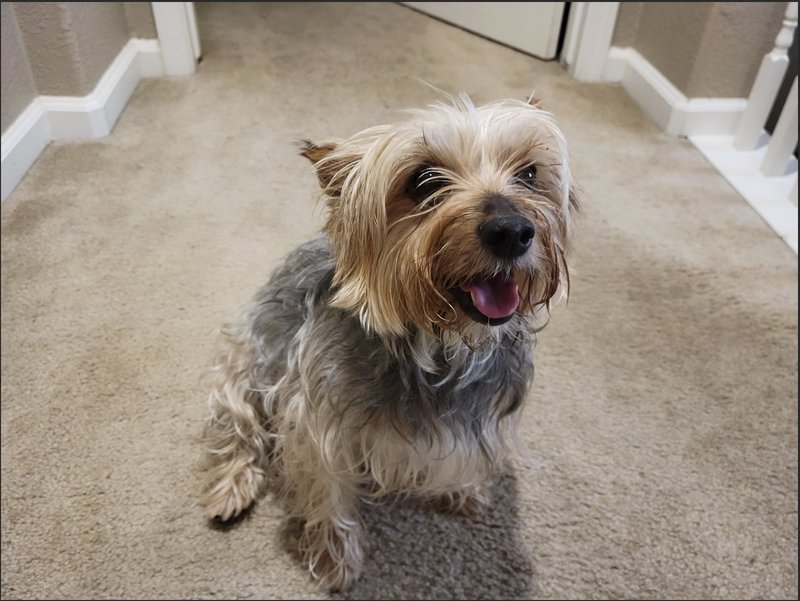

Congrats on finishing Homework 2!

---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_